In [10]:
# importing libraries
import torch
from torch import nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

In [15]:
from dataset.dataset import createDatasets
from torch.utils.data import DataLoader

dataset = pd.read_csv("./ranking_dataset.csv") 
(train_dataset, test_dataset, valid_dataset),(train_size, test_size, valid_size) = createDatasets(dataset,.1,.1)

train_data = DataLoader(train_dataset,batch_size=64)
valid_data = DataLoader(valid_dataset,batch_size=4096)
test_data = DataLoader(test_dataset,batch_size=4096)

In [51]:
import torch
from torch import nn
import numpy as np

class AddAndNormalise(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x,y):
        h = torch.concat([x,y],dim = -1)
        return (h - h.mean())/h.std()


class MultiHeadAttention(nn.Module):
    def __init__(self,nheads,input_dim,attention_layers,device):
        super().__init__()
        self.device = device
        self.W_Q = nn.Parameter(torch.randn((input_dim,attention_layers*nheads)))
        self.W_K = nn.Parameter(torch.randn((input_dim,attention_layers*nheads)))
        self.W_V = nn.Parameter(torch.randn((input_dim,attention_layers*nheads)))
        self.W_O = nn.Parameter(torch.randn((attention_layers*nheads,attention_layers*nheads)))
        
        self.sf = nn.Softmax(dim=-1)
        self.attention_layers = attention_layers
        self.nheads = nheads

    def forward(self,x):
        batchsize, input_len = x.shape[0],x.shape[1]
        Q = x@self.W_Q
        K = x@self.W_K
        V = x@self.W_V

        """
        previous attempt
        Qs = torch.chunk(Q,self.nheads,dim = -1)
        Ks = torch.chunk(K,self.nheads,dim = -1)
        Vs = torch.chunk(V,self.nheads,dim = -1)
        c = torch.concat([self.scaledDotProduct(Qs[i],Ks[i],Vs[i]) for i in range(self.nheads)],dim=-1)
        return c@self.W_O
        """
        
        Qs = Q.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)
        Ks = K.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)
        Vs = V.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)

        out = self.scaledDotProduct(Qs,Ks,Vs).transpose(1,2).reshape(batchsize,input_len,-1)
        return out@self.W_O
        

    def scaledDotProduct(self,Q,K,V):
        return self.sf(1/torch.sqrt(torch.Tensor([Q.shape[-1]]).to(self.device))*(Q@(K.mT)))@V


class EncoderOnlyTransformerPredictor2(torch.nn.Module):
    def __init__(self,device):
        super().__init__()
        self.device = device
        self.att = MultiHeadAttention(4,2,16,device)
        self.norm = AddAndNormalise()
        self.W_1 = nn.Parameter(torch.randn((4*16+2,64)))
        self.b_1 = nn.Parameter(torch.randn(64))
        self.W_2 = nn.Parameter(torch.randn((64,10)))
        self.b_2 = nn.Parameter(torch.randn(10))
        self.r = nn.ReLU()
        self.ff = lambda x : self.r(x@self.W_1+self.b_1)@self.W_2 + self.b_2

    def forward(self,x):
        x2 = self.position_embedded(x)
        x3 = self.att(x2)
        #print(x3.shape)
        x4 = self.norm(x2,x3)
        
        return self.ff(x4).reshape(-1,x.shape[-1]*x.shape[-1])

    def position_embedded(self,x):
        x = x.reshape(-1,x.shape[1],1)
        P = torch.zeros_like(x)
        for i in range(x.shape[1]):
            P[:,i,0] = 2**(-i)
        return torch.concat([x,P], dim = -1).to(self.device)


In [52]:
model = EncoderOnlyTransformerPredictor2(device)
model.to(device)
model.load_state_dict(torch.load("./model1780145736.8573117.trhmodel"))

<All keys matched successfully>

In [53]:
model.eval()

EncoderOnlyTransformerPredictor2(
  (att): MultiHeadAttention(
    (sf): Softmax(dim=-1)
  )
  (norm): AddAndNormalise()
  (r): ReLU()
)

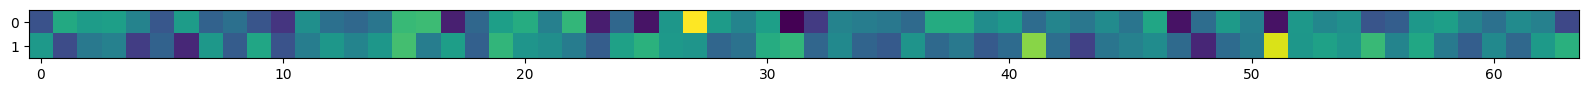

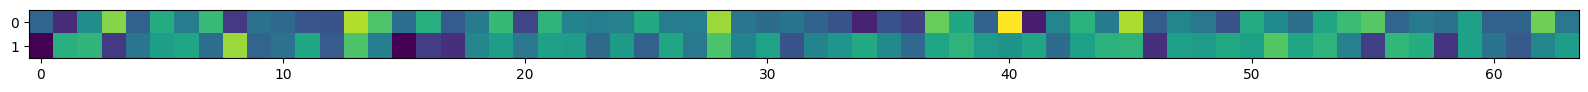

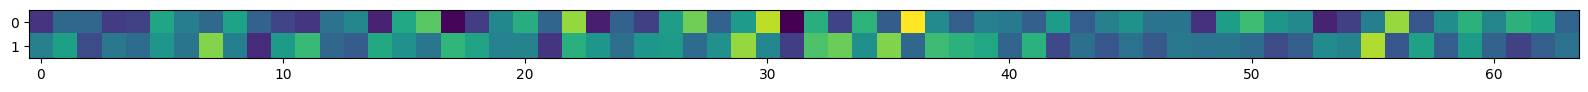

In [54]:
model.eval()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_Q.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_V.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_K.cpu().detach().numpy())
plt.show()

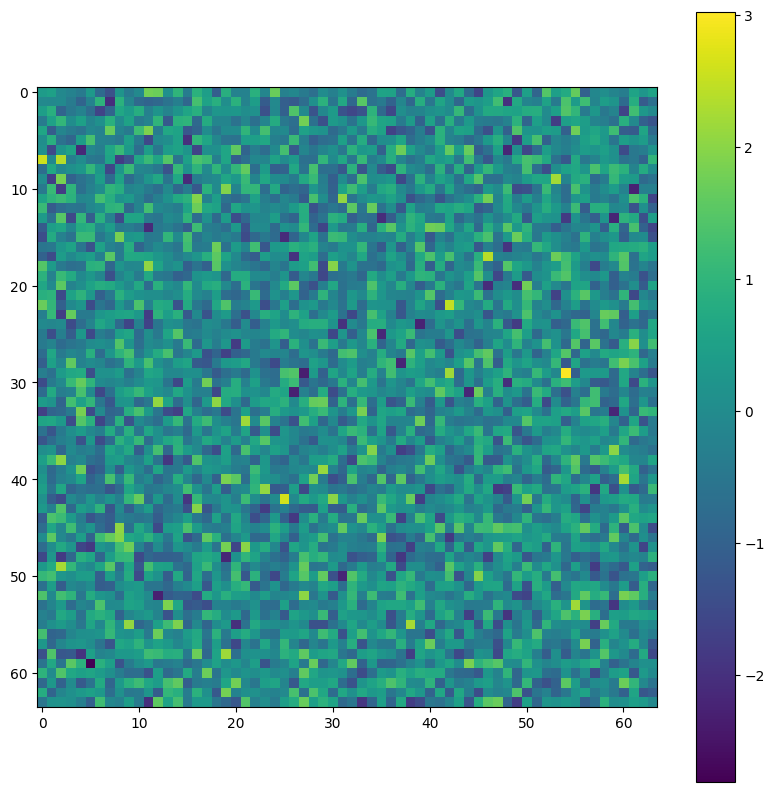

In [55]:
plt.figure(figsize=(10, 10))
plt.imshow(model.att.W_O.cpu().detach().numpy())
plt.colorbar()

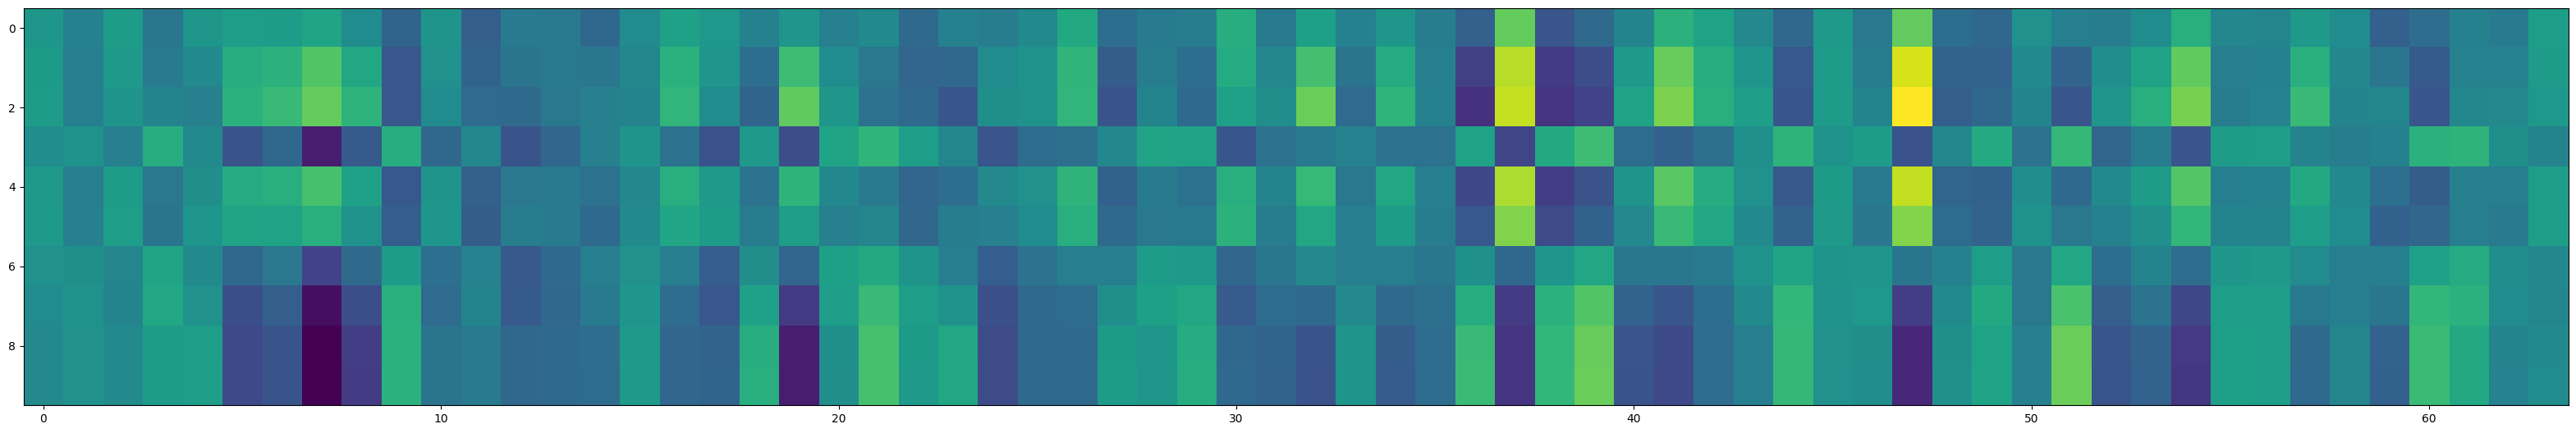

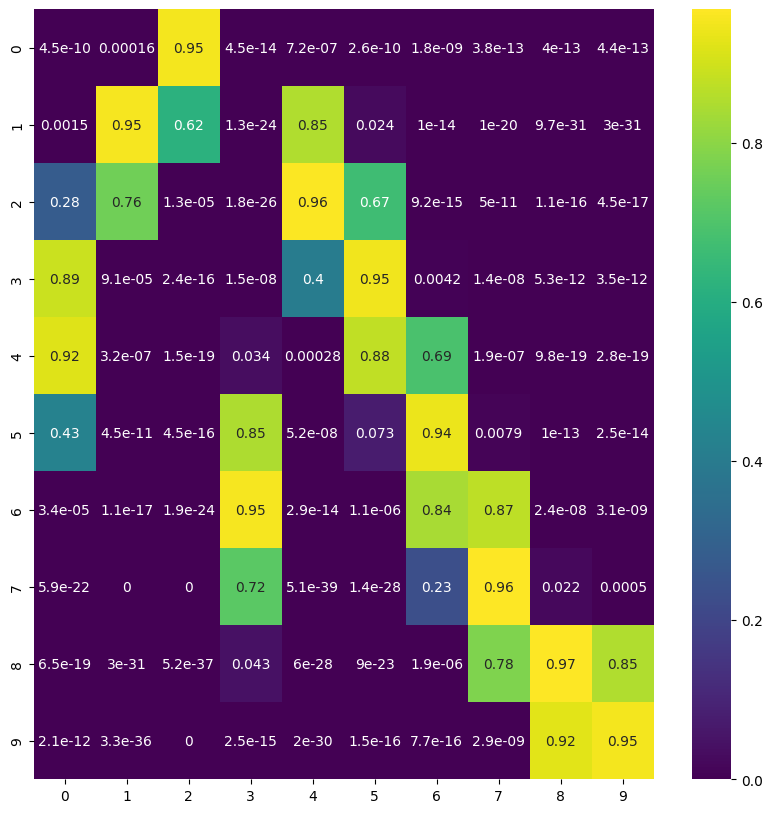

[4 1 0 6 2 3 5 7 8 9]
tensor([[4, 1, 0, 6, 2, 3, 5, 7, 8, 9]])


In [56]:
x,y = test_dataset[0]
x = x.reshape(1,-1).to(device)
x2 = model.position_embedded(x)
x3 = model.att(x2)
plt.figure(figsize=(40, 20))
plt.imshow(x3.cpu().detach().numpy()[0])
plt.show()
#print(x3.shape)
x4 = model.norm(x2,x3)
x5 = model.ff(x4)
plt.figure(figsize=(10, 10))
sns.heatmap(torch.sigmoid(x5.mT).cpu().detach().numpy()[0],annot=True,cmap="viridis")
plt.show()
print(np.argmax(y.reshape((10,10)),axis=1))
print(torch.argmax(torch.sigmoid(x5.mT).cpu(),dim=1))

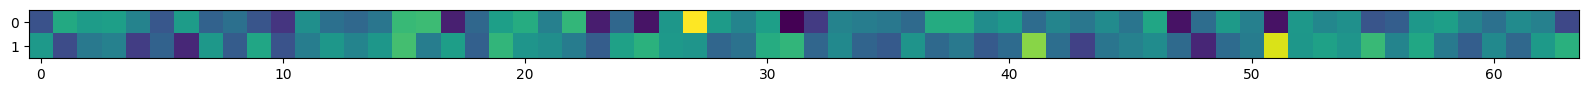

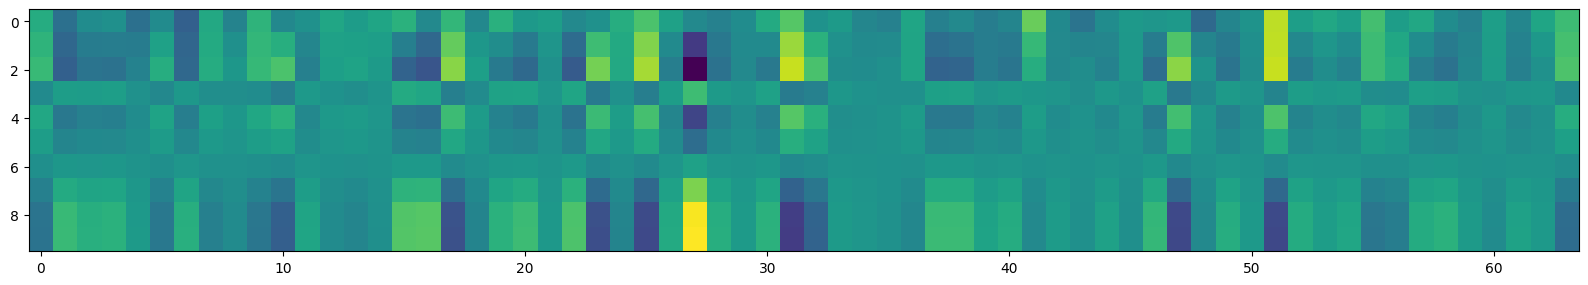

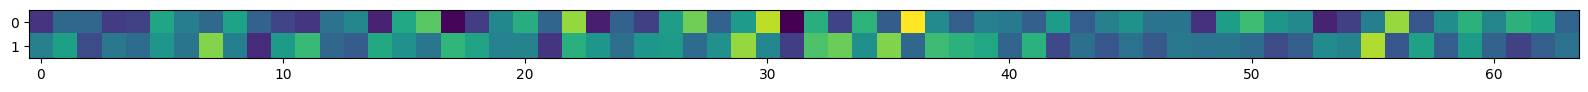

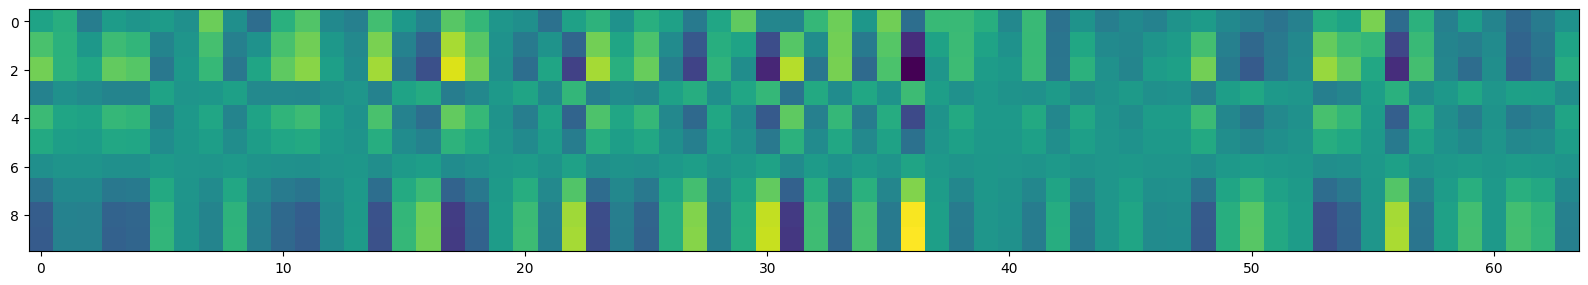

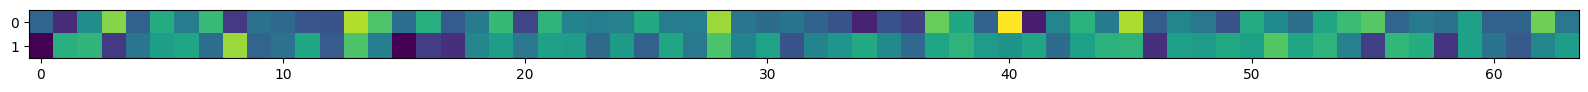

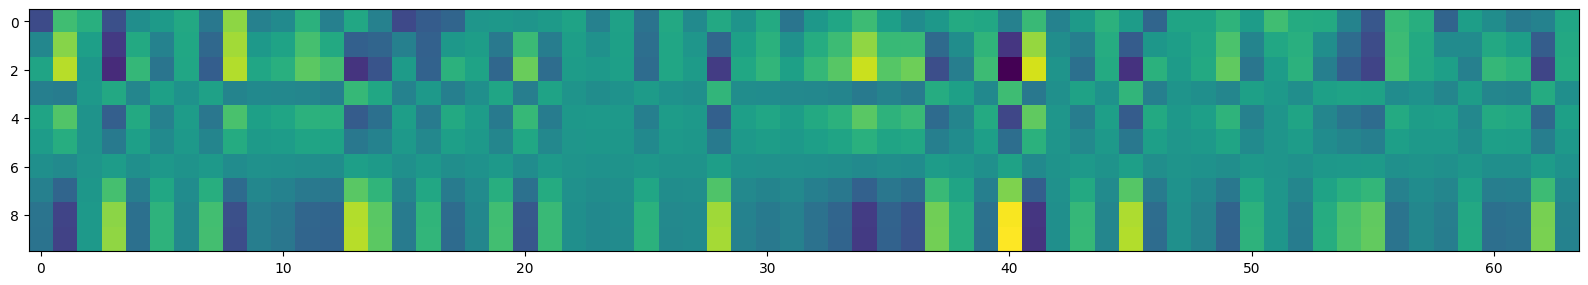

In [57]:
Q = x2@model.att.W_Q
K = x2@model.att.W_K
V = x2@model.att.W_V
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_Q.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(Q.cpu().detach().numpy()[0])
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_K.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(K.cpu().detach().numpy()[0])
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_V.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(V.cpu().detach().numpy()[0])
plt.show()

torch.Size([1, 10, 16])


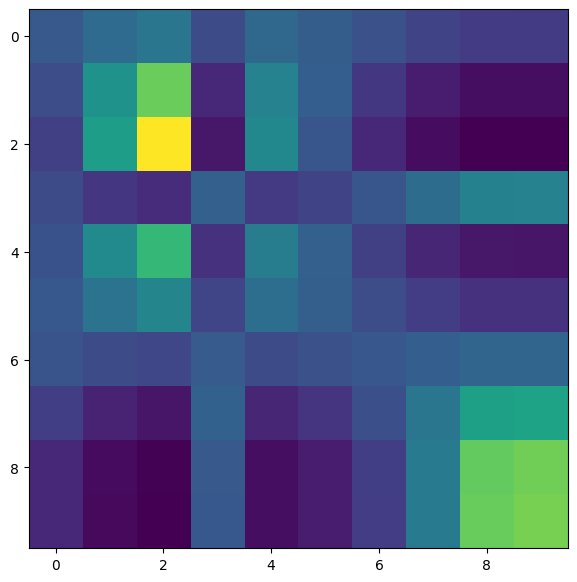

[4 1 0 6 2 3 5 7 8 9]
tensor([[4, 1, 0, 6, 2, 3, 5, 7, 8, 9]])


In [58]:
# Attention score of a head

Q = (x2@model.att.W_Q)[:,:,:model.att.attention_layers]
K = (x2@model.att.W_K)[:,:,:model.att.attention_layers]
V = (x2@model.att.W_V)[:,:,:model.att.attention_layers]

att_sc = model.att.sf(Q@(K.mT))
print(Q.shape)
plt.figure(figsize=(7, 7))
plt.imshow(att_sc.cpu().detach().numpy()[0])
plt.show()

print(np.argmax(y.reshape((10,10)),axis=1))
print(torch.argmax(torch.sigmoid(x5.mT).cpu(),dim=1))

torch.Size([1, 10, 16])


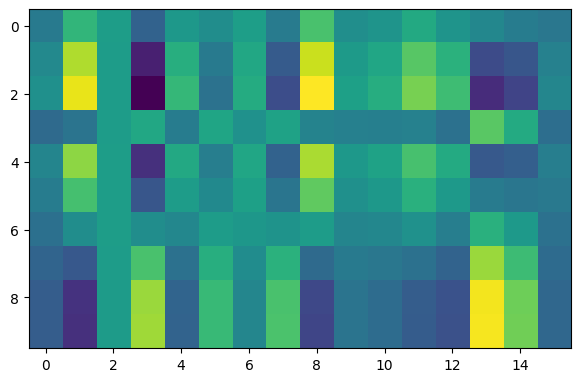

[4 1 0 6 2 3 5 7 8 9]
tensor([[4, 1, 0, 6, 2, 3, 5, 7, 8, 9]])


In [59]:
# after applying Attention score 
W = att_sc@V
print(Q.shape)
plt.figure(figsize=(7, 7))
plt.imshow(W.cpu().detach().numpy()[0])
plt.show()

print(np.argmax(y.reshape((10,10)),axis=1))
print(torch.argmax(torch.sigmoid(x5.mT).cpu(),dim=1))

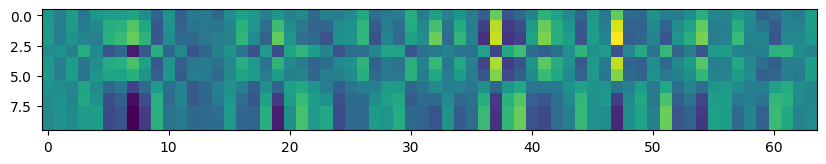

In [60]:
plt.figure(figsize=(10,10))
plt.imshow(x3.cpu().detach().numpy()[0])
plt.show()

tensor([-1.4863, -1.1560, -0.8257, -0.4954, -0.1651,  0.1651,  0.4954,  0.8257,
         1.1560,  1.4863])
tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])


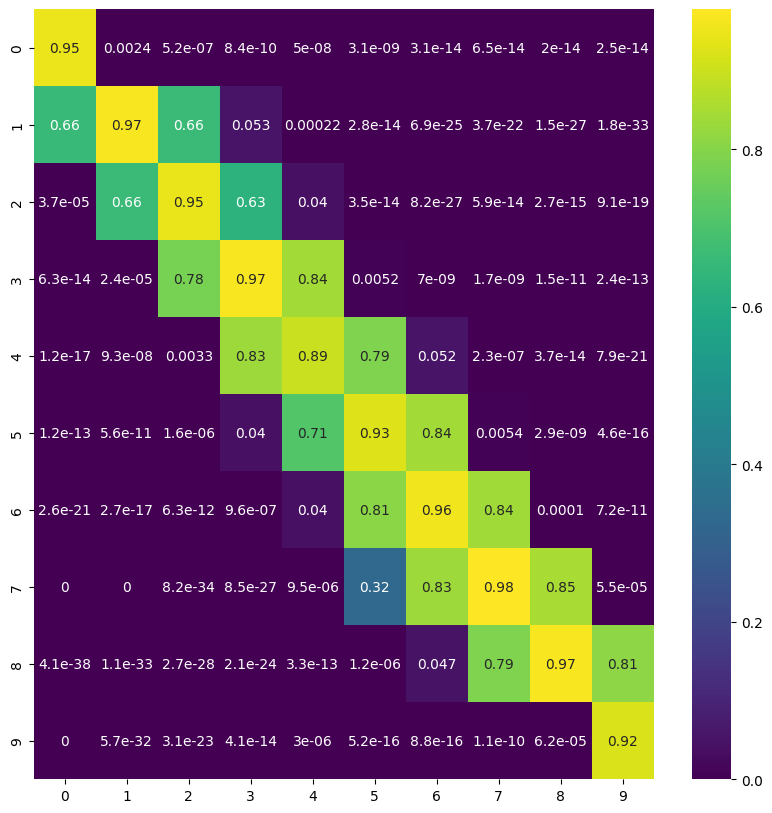

In [61]:
# Testing some examples

test = torch.Tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
test = (test - test.mean())/test.std()
x5 = model(test.reshape(1,-1)).reshape(-1,10,10)
plt.figure(figsize=(10, 10))
print(test)
print(torch.argmax(torch.sigmoid(x5.mT).cpu(),dim=1))
sns.heatmap(torch.sigmoid(x5.mT).cpu().detach().numpy()[0],annot=True,cmap="viridis")
plt.show()

tensor([ 1.4863,  1.1560,  0.8257,  0.4954,  0.1651, -0.1651, -0.4954, -0.8257,
        -1.1560, -1.4863])
tensor([[9, 8, 7, 6, 5, 4, 3, 2, 1, 0]])


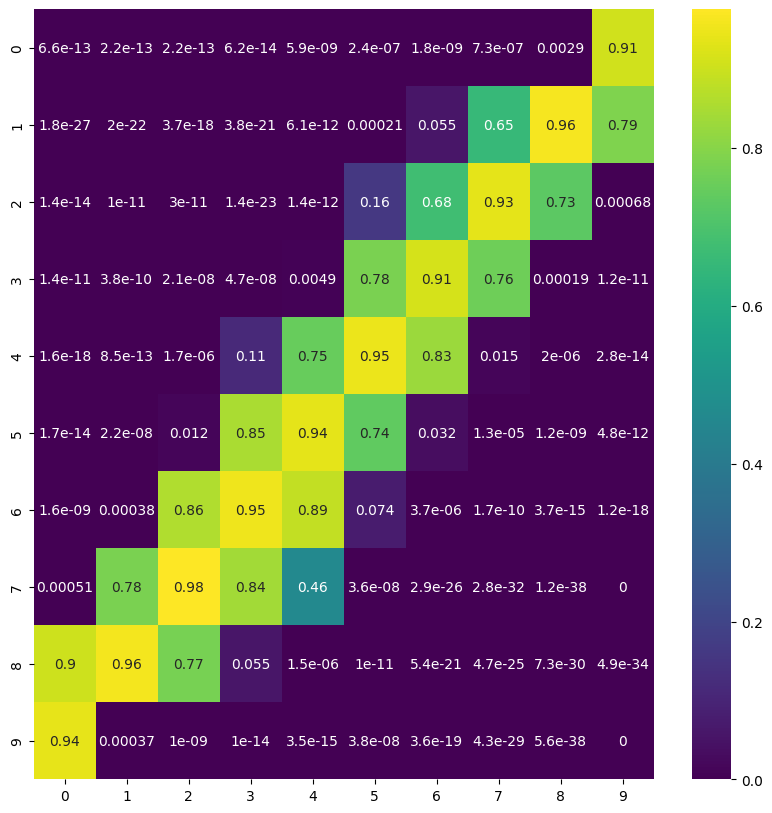

In [62]:
# Testing some examples

test = torch.Tensor([1000,900,800,700,600,500,400,300,200,100])
test = (test - test.mean())/test.std()
x5 = model(test.reshape(1,-1)).reshape(-1,10,10)
plt.figure(figsize=(10, 10))
print(test)
print(torch.argmax(torch.sigmoid(x5.mT).cpu(),dim=1))
sns.heatmap(torch.sigmoid(x5.mT).cpu().detach().numpy()[0],annot=True,cmap="viridis")
plt.show()

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([[5, 5, 5, 5, 5, 5, 5, 5, 5, 5]])


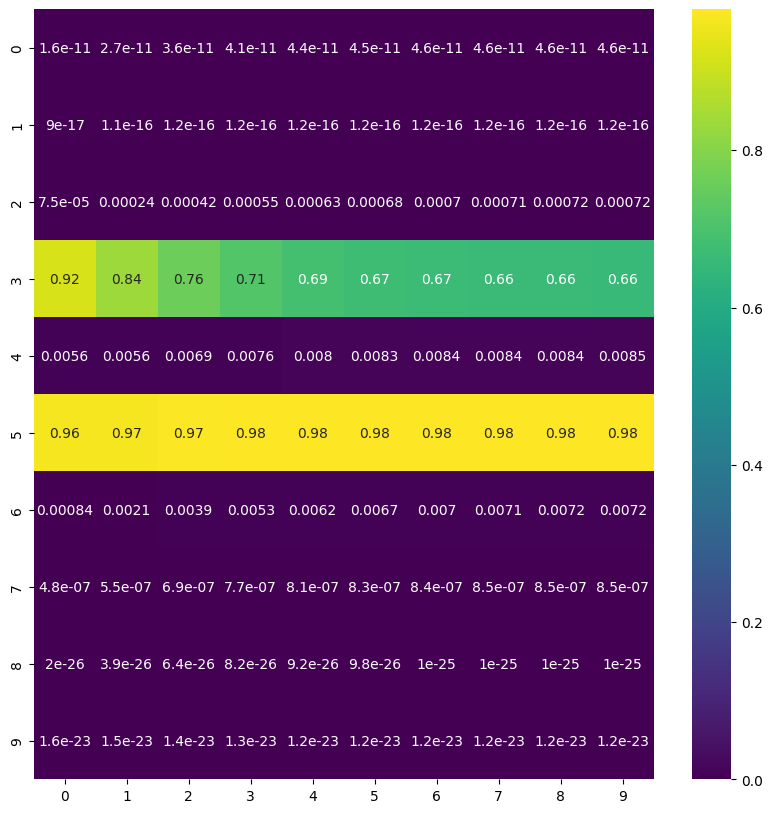

In [68]:
# Testing some examples

test = torch.Tensor([0,0,0,0,0,0,0,0,0,0])
test = (test - test.mean())

x5 = model(test.reshape(1,-1)).reshape(-1,test.shape[-1],test.shape[-1])
plt.figure(figsize=(10, 10))
print(test)
print(torch.argmax(torch.sigmoid(x5.mT).cpu(),dim=1))
sns.heatmap(torch.sigmoid(x5.mT).cpu().detach().numpy()[0],annot=True,cmap="viridis")
plt.show()